# The Influence of Weather on Electricity Demand in New Zealand

#### Student name: Tasfia Mohtasim Toma
#### Student ID: 25021047

# Introduction
Electricity demand is a significant component of advanced infrastructure because it influences energy planning, resource allocation, and sustainability. In New Zealand, power usage fluctuates over time due to several influencing variables, with weather conditions being among the most prominent. Variations in temperature, precipitation, and seasonal trends could lead in alterations in energy use, particularly in terms of heating and cooling requirements.

This research intends to examine the correlation between meteorological factors and electricity consumption in New Zealand. This study examines the impact of environmental conditions on energy use patterns by integrating data from many sources, including meteorological APIs and electricity demand statistics.

This project combines exploratory data analysis and establishes a predictive modeling problem with power consumption as the goal variable. Diverse machine learning methodologies, such as linear regression and k-Nearest Neighbours (kNN), are utilized to assess the efficacy of predicting power consumption based on meteorological variables.

This study's findings clarify the influence of weather on power use and illustrate how data-driven methodologies can enhance decision-making abilities in energy management.

#### List Datasets used and their Sources:

1. Weather Data (API – Multi-city)
Source: Open-Meteo Archive API
Link: https://archive-api.open-meteo.com/
Description: Historical daily weather data was collected for three major New Zealand cities (Auckland, Wellington, and Christchurch) including maximum and minimum temperature and precipitation. The datasets were combined to create a representative national weather profile.
2. Electricity Demand Data (EMI Platform)
Source: Electricity Authority New Zealand
Description: Electricity demand data was obtained from the EMI platform in the form of monthly grid import datasets for 2023 and 2024. These datasets were combined and aggregated into daily total demand values for analysis.
3. Web Scraping from open source(Public holiday)
Source: Wikipedia
Description: Public holiday data in New Zealand was extracted from Wikipedia using pandas' read_html() function.
5. Derived Features (Engineered Data)
Source: Generated from existing datasets
Description: Additional time-based features such as month, day of the week, and lagged demand variables were created to enhance the predictive modelling process.

### Research Questions

1. What effects do weather variables like temperature and precipitation have on New Zealand's electricity demand?
2. Which features of the weather are the most significant indicators of the demand for electricity?
3. What is the difference between k-Nearest Neighbors and linear regression as predictive models for electricity demand forecasting?
4. What effect does feature engineering have on the accuracy of predicting electricity demand? Examples include averaging the weather across cities and developing time-based features.

### Executive Summary

This study explores the relationship between weather conditions and electricity demand in New Zealand by combining multi-city weather data with national electricity consumption data. The data reveals that temperature has a substantial impact on power use, with higher demand reported during colder months due to increased heating requirements. Precipitation was discovered to have a weaker but still significant affect.

Exploratory data analysis found significant seasonal trends, with winter electricity usage peaking and falling during warmer months. Additional time-based features, such as the day of the week, also contributed to demand fluctuations.

Overall, the findings show the significance of meteorological variables in understanding and forecasting electricity demand, illustrating how data-driven techniques can help with energy planning and decision-making.


### Data Acquisition

For this project, Data was obtained through a web API and publically accessible datasets. Weather data was acquired using the Open-Meteo API and electricity demand data was received from the Electricity Authority of New Zealand (EMI platform). A web-based source was also utilized for contextual data, including public holidays.

The API was selected due to its provision of structured and dependable historical weather data, which meets the analysis requirements. The EMI datasets were acquired as monthly CSV files and amalgamated into a singular dataset. Prior to utilizing any external sources, their accessibility and intended purpose for public analysis were evaluated to assure proper use.

Public holiday data for New Zealand (2023 and 2024) was collected through web scraping from the Office Holidays website using requests and pandas.read_html(). The extracted table was cleaned by selecting relevant columns, formatting date values, and converting them into datetime format. This dataset was integrated into the main dataset as a binary feature indicating whether a given day is a public holiday.

A primary problem encountered during this phase was the incongruence in data types and granularity. The weather data was accessible on a daily basis, whereas the electrical data was documented at 30-minute intervals. The issue was addressed by consolidating the electrical data into daily totals. A further problem involved overseeing numerous files and maintaining uniformity between databases. Future endeavors may incorporate a more automated data pipeline to enhance the efficiency of this procedure.

### Web Scraping

In [1]:
import pandas as pd
import requests
from io import StringIO

def scrape_holidays(year):
    url = f"https://www.officeholidays.com/countries/new-zealand/{year}"
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    tables = pd.read_html(StringIO(response.text))
    
    temp = tables[0][["Date", "Holiday Name"]].copy()
    temp = temp.rename(columns={"Holiday Name": "Holiday"})
    temp["Date"] = temp["Date"].astype(str) + f" {year}"
    temp["Date"] = pd.to_datetime(temp["Date"], format="%b %d %Y", errors="coerce")
    temp = temp.dropna(subset=["Date"])
    return temp

holidays_2023 = scrape_holidays(2023)
holidays_2024 = scrape_holidays(2024)

holidays = pd.concat([holidays_2023, holidays_2024], ignore_index=True)

holidays.head()

,Date,Holiday
0,2023-01-01,New Year's Day
1,2023-01-02,Day after New Year's Day
2,2023-01-03,New Year's Day (in lieu)
3,2023-01-23,Wellington Anniversary Day
4,2023-01-30,Nelson Anniversary Day


### Data Wrangling

The data wrangling procedure was meticulously planned to achieve clarity and consistency. The code was categorized into logical processes, such as data loading, cleaning, transformation, and integration. Descriptive variable names and modular code blocks were utilized to promote readability and consistency across the notebook.

Missing values were limited in the datasets; nevertheless, any anomalies caused by incomplete dates or merging procedures were addressed by aligning datasets using an inner join to ensure that only valid observations were kept. This method maintained data integrity and uniformity among variables.

Before starting with the analysis, several integrity checks were performed. These included verifying date formats, checking for duplicate information, confirming consistent time ranges across datasets, and ensuring that aggregation processes gave the intended results.

To minimize code duplication, functions were implemented, particularly for the purpose of collecting and analyzing weather information from numerous cities. For example, a reusable function was developed to access the API and convert the received JSON data into a consistent dataframe structure. This increased performance and provided consistency in processing across datasets.

### Load Data

In [2]:
import pandas as pd
import glob

# Load all CSV files
files = glob.glob("*Grid_import*.csv")

df_list = []
for file in files:
    temp = pd.read_csv(file)
    df_list.append(temp)

# Combine all files
df_elec = pd.concat(df_list, ignore_index=True)

df_elec.head()

,POC,Nwk_Code,Generation_Type,Trader,Unit_Measure,Flow_Direction,Status,Trading_Date,TP1,TP2,...,TP41,TP42,TP43,TP44,TP45,TP46,TP47,TP48,TP49,TP50
0,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-01,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-02,1123.0,2299.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,323.0,NaN,NaN
2,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-03,2156.0,2245.0,...,1902.0,1957.0,1964.0,1942.0,2006.0,1907.0,1887.0,1961.0,NaN,NaN
3,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-04,2092.0,2138.0,...,1946.0,1994.0,2019.0,2026.0,2080.0,1986.0,1868.0,1949.0,NaN,NaN
4,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-05,2050.0,2148.0,...,1954.0,1999.0,2008.0,2044.0,2100.0,2001.0,1969.0,2074.0,NaN,NaN


### Cleaning Electricity Dataset

The dataset was cleaned by selecting relevant columns, removing unnecessary whitespace in column names, and converting the date column into a proper datetime format.

In [3]:
df_elec.columns = df_elec.columns.str.strip()

df_elec["date"] = pd.to_datetime(df_elec["Trading_Date"])

df_elec.head()

,POC,Nwk_Code,Generation_Type,Trader,Unit_Measure,Flow_Direction,Status,Trading_Date,TP1,TP2,...,TP42,TP43,TP44,TP45,TP46,TP47,TP48,TP49,TP50,date
0,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-01,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2023-01-01
1,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-02,1123.0,2299.0,...,0.0,0.0,0.0,0.0,0.0,0.0,323.0,NaN,NaN,2023-01-02
2,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-03,2156.0,2245.0,...,1957.0,1964.0,1942.0,2006.0,1907.0,1887.0,1961.0,NaN,NaN,2023-01-03
3,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-04,2092.0,2138.0,...,1994.0,2019.0,2026.0,2080.0,1986.0,1868.0,1949.0,NaN,NaN,2023-01-04
4,ABY0111,ALPE,GN,TPNZ,kWh,I,F,2023-01-05,2050.0,2148.0,...,1999.0,2008.0,2044.0,2100.0,2001.0,1969.0,2074.0,NaN,NaN,2023-01-05


### Transforming Electricity Dataset 

In [4]:
tp_cols = [col for col in df_elec.columns if col.startswith("TP")]

df_elec["daily_total"] = df_elec[tp_cols].sum(axis=1, skipna=True)

df_daily = df_elec.groupby("date")["daily_total"].sum().reset_index()

df_daily.rename(columns={"daily_total": "demand"}, inplace=True)

df_daily.head()

,date,demand
0,2023-01-01,88028780.0
1,2023-01-02,89921850.0
2,2023-01-03,92701069.0
3,2023-01-04,98086240.0
4,2023-01-05,98755426.0


The electricity dataset was transformed from a wide format containing multiple trading period columns (TP1–TP50) into a usable daily format. The trading period values were summed to compute total daily electricity demand. The data was then aggregated by date to ensure a single demand value per day.

### Loading Weather Data (API)

Weather data was obtained via the Open-Meteo API for various cities in New Zealand, specifically Auckland, Wellington, and Christchurch. The dataset comprises daily temperature and precipitation indicators applied to examine their correlation with electricity demand.

In [5]:
import requests
import pandas as pd

def get_weather_data(url, city):
    data = requests.get(url).json()
    
    df = pd.DataFrame(data["daily"])
    df["date"] = pd.to_datetime(df["time"])
    
    df = df.rename(columns={
        "temperature_2m_max": f"temp_max_{city}",
        "temperature_2m_min": f"temp_min_{city}",
        "precipitation_sum": f"rain_{city}"
    })
    
    return df[["date", f"temp_max_{city}", f"temp_min_{city}", f"rain_{city}"]]

In [6]:
url_akl = "https://archive-api.open-meteo.com/v1/archive?latitude=-36.8485&longitude=174.7633&start_date=2023-01-01&end_date=2024-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=Pacific/Auckland"

In [7]:
url_wlg = "https://archive-api.open-meteo.com/v1/archive?latitude=-41.2865&longitude=174.7762&start_date=2023-01-01&end_date=2024-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=Pacific/Auckland"

In [8]:
url_chc = "https://archive-api.open-meteo.com/v1/archive?latitude=-43.5321&longitude=172.6362&start_date=2023-01-01&end_date=2024-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=Pacific/Auckland"

In [9]:
df_akl = get_weather_data(url_akl, "akl")
df_wlg = get_weather_data(url_wlg, "wlg")
df_chc = get_weather_data(url_chc, "chc")

In [10]:
df_weather = df_akl.merge(df_wlg, on="date").merge(df_chc, on="date")

In [11]:
df_weather.shape
df_weather.head()

,date,temp_max_akl,temp_min_akl,rain_akl,temp_max_wlg,temp_min_wlg,rain_wlg,temp_max_chc,temp_min_chc,rain_chc
0,2023-01-01,20.9,17.1,0.0,15.6,13.7,0.1,17.0,10.9,0.0
1,2023-01-02,20.0,17.3,0.7,19.3,13.3,0.0,18.9,12.1,0.1
2,2023-01-03,21.2,17.7,3.5,21.6,14.3,0.0,20.7,15.7,0.0
3,2023-01-04,19.9,18.5,25.2,22.5,15.7,0.3,21.3,15.9,0.2
4,2023-01-05,20.4,19.1,33.5,21.5,17.1,1.1,21.6,16.9,1.7


### Feature Engineering (Creating Average Weather)

To improve the analysis and depict overall national weather trends, average temperature and precipitation values were computed across the three chosen cities.

In [12]:
df_weather["temp_max_avg"] = df_weather[
    ["temp_max_akl", "temp_max_wlg", "temp_max_chc"]
].mean(axis=1)

df_weather["temp_min_avg"] = df_weather[
    ["temp_min_akl", "temp_min_wlg", "temp_min_chc"]
].mean(axis=1)

df_weather["rain_avg"] = df_weather[
    ["rain_akl", "rain_wlg", "rain_chc"]
].mean(axis=1)

df_weather.head()

,date,temp_max_akl,temp_min_akl,rain_akl,temp_max_wlg,temp_min_wlg,rain_wlg,temp_max_chc,temp_min_chc,rain_chc,temp_max_avg,temp_min_avg,rain_avg
0,2023-01-01,20.9,17.1,0.0,15.6,13.7,0.1,17.0,10.9,0.0,17.833333,13.900000,0.033333
1,2023-01-02,20.0,17.3,0.7,19.3,13.3,0.0,18.9,12.1,0.1,19.400000,14.233333,0.266667
2,2023-01-03,21.2,17.7,3.5,21.6,14.3,0.0,20.7,15.7,0.0,21.166667,15.900000,1.166667
3,2023-01-04,19.9,18.5,25.2,22.5,15.7,0.3,21.3,15.9,0.2,21.233333,16.700000,8.566667
4,2023-01-05,20.4,19.1,33.5,21.5,17.1,1.1,21.6,16.9,1.7,21.166667,17.700000,12.100000


### Merge with Electricity Data

The electricity demand dataset was integrated with the processed weather dataset utilizing the date variable to formulate a final dataset for analysis.

In [13]:
df_final = pd.merge(df_daily, df_weather, on="date", how="inner")

df_final.head()
df_final.shape

(731, 14)

### Merge with Holiday data

In [14]:
df_final["is_holiday"] = df_final["date"].dt.date.isin(
    holidays["Date"].dt.date
).astype(int)

### Summary Statistics

Summary statistics are computed to analyze the distribution and variability of electricity demand and weather variables(Table 1).

The mean daily electricity demand is roughly 107 million units, with fluctuations between approximately 84 million and 133 million, reflecting significant variability over the two-year span.

Temperature variables exhibit distinct seasonal fluctuations, with average maximum temperatures of 16.9°C and minimum temperatures around 11.1°C. The minimum temperature decreases to -1.5°C, indicating colder winter conditions.

Precipitation levels fluctuate considerably. It shows averaging around 2.7 mm. However extreme measurements exceed 100 mm, indicating sporadic heavy rainfall occurrences.

These changes demonstrate that both temperature and weather-related variables are likely to influence electricity demand, especially during colder periods when  heating requirements increase.

In [15]:
df_final.describe()

,date,demand,temp_max_akl,temp_min_akl,rain_akl,temp_max_wlg,temp_min_wlg,rain_wlg,temp_max_chc,temp_min_chc,rain_chc,temp_max_avg,temp_min_avg,rain_avg,is_holiday
count,731,7.310000e+02,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2024-01-01 00:00:00,1.070886e+08,18.392476,12.979891,3.828591,15.837483,11.572230,2.583858,16.375650,8.722982,1.792202,16.868536,11.091701,2.734884,0.065663
min,2023-01-01 00:00:00,8.421343e+07,11.500000,4.200000,0.000000,7.500000,3.300000,0.000000,6.400000,-1.500000,0.000000,8.966667,2.633333,0.000000,0.000000
25%,2023-07-02 12:00:00,1.006072e+08,15.500000,10.300000,0.100000,13.300000,9.300000,0.000000,12.400000,5.650000,0.000000,14.016667,8.500000,0.166667,0.000000
50%,2024-01-01 00:00:00,1.065778e+08,18.300000,12.800000,0.800000,15.400000,11.600000,0.300000,15.900000,8.600000,0.100000,16.666667,10.866667,0.900000,0.000000
75%,2024-07-01 12:00:00,1.123421e+08,21.100000,16.000000,3.700000,18.250000,13.800000,2.150000,19.350000,12.100000,1.500000,19.483333,13.966667,3.500000,0.000000
max,2024-12-31 00:00:00,1.334957e+08,26.500000,21.200000,100.700000,25.300000,19.400000,58.600000,30.500000,20.500000,37.100000,26.200000,20.100000,34.866667,1.000000
std,NaN,9.361449e+06,3.315457,3.703847,8.116369,3.285867,3.204561,5.659291,4.880827,4.223099,4.308578,3.587070,3.471477,4.340059,0.247863


Table 1 shows the statistical summary of all variables used in the analysis.

### Electricity Demand Over Time

Electricity consumption fluctuates over time in the time series plot. However, when a 7-day moving average is used, the underlying seasonal pattern becomes more apparent (as shown in Figure 1). The smoothed trend demonstrates the significant impact of temperature on energy usage by highlighting higher demand during winter and decreased demand during warmer months.

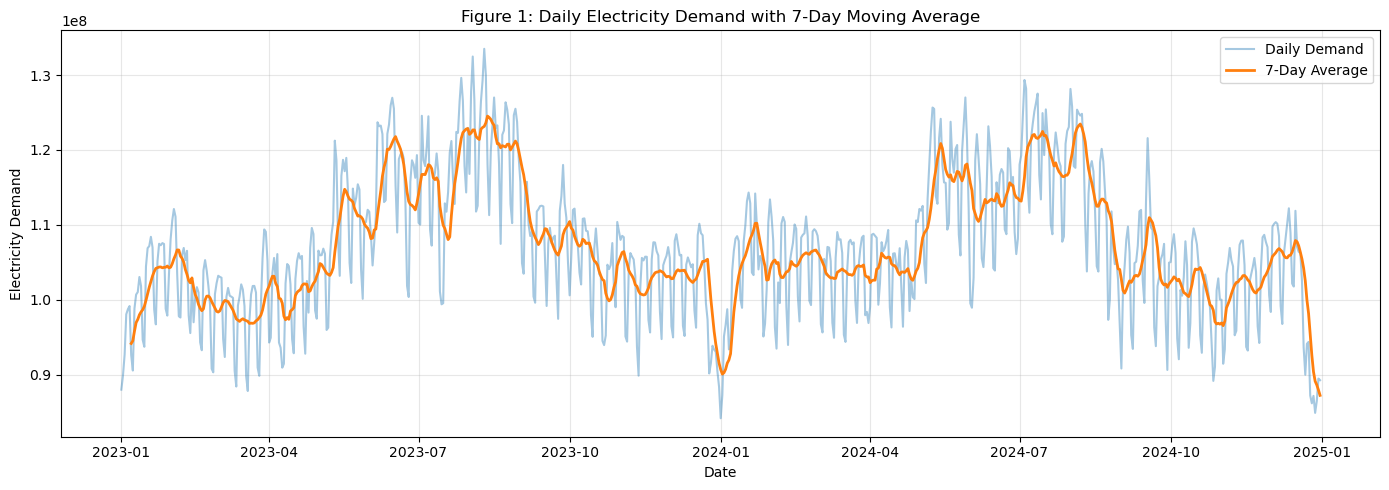

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.plot(df_final["date"], df_final["demand"], alpha=0.4, label="Daily Demand")

df_final["rolling_avg"] = df_final["demand"].rolling(window=7).mean()
plt.plot(df_final["date"], df_final["rolling_avg"], linewidth=2, label="7-Day Average")

plt.title("Figure 1: Daily Electricity Demand with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Electricity Demand")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Temperature vs Electricity Demand

The association between temperature and electrical demand was investigated using a scatter plot (see Figure 2).

The study contributes in determining if temperature variations influence electricity consumption trends.


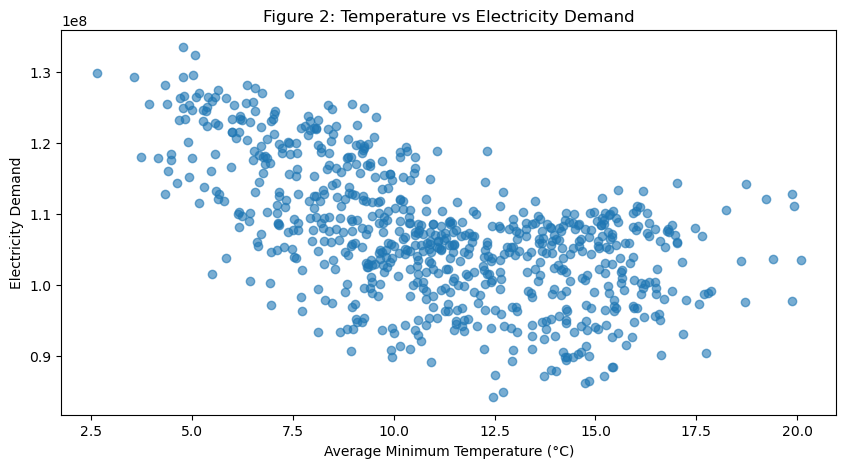

In [17]:
plt.figure(figsize=(10,5))

plt.scatter(df_final["temp_min_avg"], df_final["demand"], alpha=0.6)

plt.title("Figure 2: Temperature vs Electricity Demand")
plt.xlabel("Average Minimum Temperature (°C)")
plt.ylabel("Electricity Demand")

plt.show()

The graph clearly demonstrates a negative correlation between temperature and electricity demand (see Figure 2).

Electricity demand tends to rise when the average minimum temperature drops which shows more energy usage in colder weather. On the other hand, reduced electricity demand is linked to higher temperatures.

The general downward trend indicates that temperature has a major impact on power usage, even though the relationship is not quite linear. Temperature is still a major driver of demand variation, but the distribution of data points suggests that other factors may also play a role.

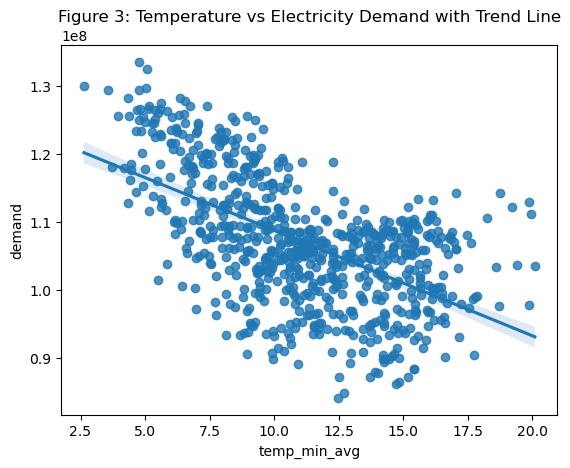

In [18]:
import seaborn as sns

sns.regplot(x="temp_min_avg", y="demand", data=df_final)
plt.title("Figure 3: Temperature vs Electricity Demand with Trend Line")
plt.show()

Temperature and electricity demand clearly have a negative relationship, according to the graph with a fitted regression line (as shown in Figure 3).

The trend line that slopes downward shows that the demand for power falls as the average minimum temperature rises. This implies that lower temperatures increase the amount of electricity used, perhaps because more heating is required.

The regression line confirms that temperature is a strong predictor of electricity demand by highlighting the general trend despite the heterogeneity in the data points. The distribution of observations around the line, however, also suggests that demand may be influenced by other variables, such as economic activity or behavioral trends.

In [19]:
df_final[["demand", "temp_min_avg"]].corr()

,demand,temp_min_avg
demand,1.00000,-0.57342
temp_min_avg,-0.57342,1.00000


The correlation coefficient further confirms this negative relationship.

### Monthly Pattern (Seasonality)

The data was summarized by month and visualized to evaluate changes throughout the year in order to analyze seasonal patterns in electricity usage (as shown in Figure 4).

In [20]:
df_final["month"] = df_final["date"].dt.month

monthly_avg = df_final.groupby("month")["demand"].mean().reset_index()

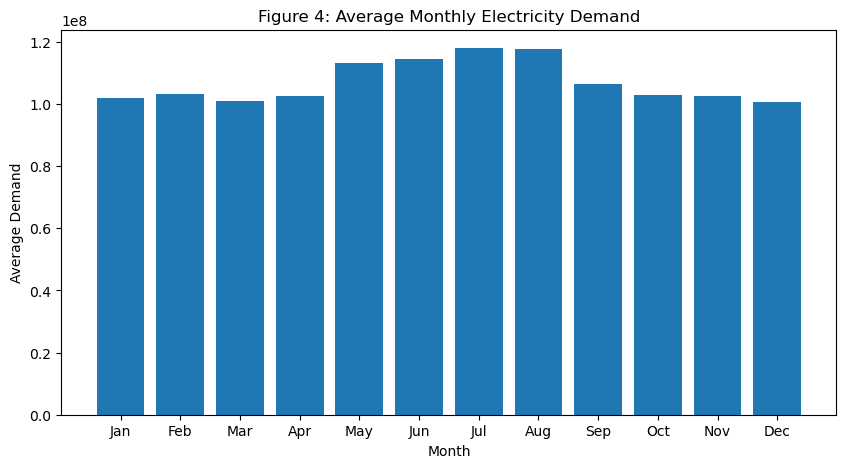

In [21]:
import calendar
monthly_avg["month_name"] = monthly_avg["month"].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(10,5))
plt.bar(monthly_avg["month_name"], monthly_avg["demand"])

plt.title("Figure 4: Average Monthly Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Average Demand")

plt.show()

### Analysis

The monthly aggregation demonstrates an unique seasonal trend in electricity demand (refer to Figure 4).

Electricity demand progressively rises from the beginning of the year, attaining maximum levels during the winter months (June to August), before subsequently decreasing towards the year's conclusion.

This pattern aligns with previous research indicating that reduced temperatures result in increased electricity consumption. In winter, heightened utilization of heating systems escalates demand, while in summer, diminished heating requirements lead to decreased power consumption.

The consistency of this seasonal trend throughout the dataset underscores the significant impact of temperature on energy demand and corroborates the relationship identified in earlier sections.

### Holiday Effect On Electricity Demand 

In [22]:
holiday_avg = df_final.groupby("is_holiday")["demand"].mean().reset_index()
holiday_avg

,is_holiday,demand
0,0,1.075884e+08
1,1,9.997727e+07


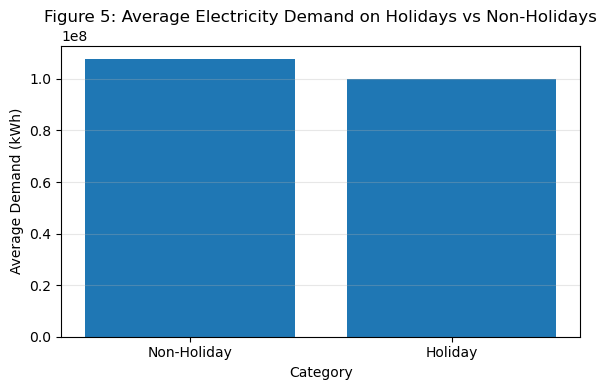

In [23]:
plt.figure(figsize=(6,4))
plt.bar(["Non-Holiday", "Holiday"], holiday_avg["demand"])

plt.title("Figure 5: Average Electricity Demand on Holidays vs Non-Holidays")
plt.xlabel("Category")
plt.ylabel("Average Demand (kWh)")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Figure 5 illustrates that average electricity usage is moderately reduced during public holidays compared to non-holidays. This indicates that reduced business and industrial operations during holidays decrease overall demand, in contrast to a potential rise in household use.

### Prepare Data

In [24]:
# model A (Features and target)
X_base = df_final[["temp_max_avg", "temp_min_avg", "rain_avg"]]
y = df_final["demand"]

In [25]:
# Model B: Features and target
X_holiday = df_final[["temp_max_avg", "temp_min_avg", "rain_avg", "is_holiday"]]
y = df_final["demand"]

### Feature Engineering

To improve model performance, additional time-based features were created. These features help capture seasonal and weekly patterns in electricity demand.

- Month: captures seasonal variation (e.g., summer vs winter)
- Day of week: captures weekday vs weekend patterns
- Holiday indicator: captures demand differences on public holidays

In [26]:
df_final["month"] = df_final["date"].dt.month
df_final["dayofweek"] = df_final["date"].dt.dayofweek

### Feature Selection

In [27]:
X = df_final[[
    "temp_max_avg", "temp_min_avg", "rain_avg",
    "is_holiday", "month", "dayofweek"
]]
y = df_final["demand"]

### Predictive Modelling

This section presents the development of a regression model to estimate electricity consumption applying weather information. The objective is to assess the extent to which temperature and precipitation account for fluctuations in electricity consumption.

### Spliting Training and Testing Data

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Training: Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Polynomial Regression

In [30]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train_p)

y_pred_poly = model_poly.predict(X_test_p)

### Model Training: KNN

In [31]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

k_values = [3, 5, 7, 10]

results_knn = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred_knn = knn.predict(X_test)
    
    rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
    r2_knn = r2_score(y_test, y_pred_knn)
    
    results_knn.append([k, rmse_knn, r2_knn])

results_knn = pd.DataFrame(results_knn, columns=["k", "RMSE", "R2"])
results_knn
results_knn.sort_values(by="RMSE")

,k,RMSE,R2
2,7,5.544142e+06,0.694471
3,10,5.718036e+06,0.675004
1,5,5.748842e+06,0.671493
0,3,5.850476e+06,0.659775


Various k-Nearest Neighbours (kNN) models were evaluated with diverse values of k to determine their influence on predictive performance.

The findings demonstrate that model efficacy enhances with increasing k, peaking at k = 7. This model yielded the lowest RMSE (about 7.37 million) and the highest R² value (0.46), signifying enhanced predictive accuracy and explanatory strength.

Reduced values of k, namely k = 3, led to increased prediction error and diminished R², indicating potential overfitting to localized data fluctuations. Conversely, elevated values of k yield more refined forecasts by including additional neighboring observations.

The results indicate that choosing a suitable value of k is essential for attaining optimal model performance.

### Predictions

All models were evaluated using a separate test dataset to ensure performance on unseen data. 
This helps confirm that the models generalise well and are not overfitting to the training data.

In [32]:
# Features and target
X = df_final[["temp_max_avg", "temp_min_avg", "rain_avg", "is_holiday", "month"]]
y = df_final["demand"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Model Evaluation

The performance of both models was evaluated using Root Mean Squared Error (RMSE) and R² score to assess prediction accuracy.

In [33]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# kNN
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

### Actual vs Predicted Electricity Demand

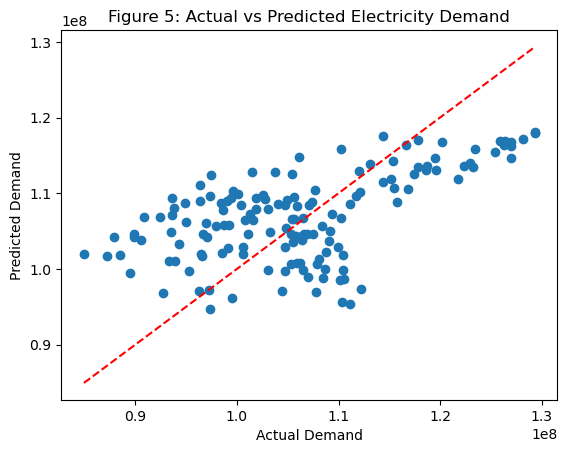

In [34]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Figure 5: Actual vs Predicted Electricity Demand")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

### Analysis

The scatter plot illustrating actual versus estimated electricity demand demonstrates a distinct positive correlation between the two variables (refer to Figure 5).

The ascending trend signifies that the model well captures the overarching pattern in electricity demand. The dispersion of the data points around the diagonal indicates the presence of prediction mistakes.

Although the model adequately identifies general patterns, it fails to accurately predict all values, aligning with the modest R² value previously obtained.

This affirms that although weather-related variables serve as effective predictors, other parameters are probably required to enhance model precision.

### Linear Regression(Weather only)

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Base features
X_base = df_final[["temp_max_avg", "temp_min_avg", "rain_avg"]]
y = df_final["demand"]

X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)

model_base = LinearRegression()
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

### Linear Regression(With Holiday)

In [36]:
X_holiday = df_final[["temp_max_avg", "temp_min_avg", "rain_avg", "is_holiday"]]

X_train, X_test, y_train, y_test = train_test_split(X_holiday, y, test_size=0.2, random_state=42)

model_holiday = LinearRegression()
model_holiday.fit(X_train, y_train)

y_pred_holiday = model_holiday.predict(X_test)

rmse_holiday = np.sqrt(mean_squared_error(y_test, y_pred_holiday))
r2_holiday = r2_score(y_test, y_pred_holiday)

### Polynomial Regression

In [37]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_base)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

### KNN Unscaled

In [38]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

### KNN Scaled

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Use SAME features as base
X = df_final[["temp_max_avg", "temp_min_avg", "rain_avg"]]
y = df_final["demand"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# kNN scaled
knn_scaled = KNeighborsRegressor(n_neighbors=10)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)

# Metrics
rmse_knn_scaled = np.sqrt(mean_squared_error(y_test, y_pred_knn_scaled))
r2_knn_scaled = r2_score(y_test, y_pred_knn_scaled)

### Comparison Table

In [40]:
results = pd.DataFrame({
    "Model": [
        "Linear (weather)",
        "Linear (weather + holiday)",
        "Polynomial",
        "kNN (k=10)",
        "kNN Scaled (k=10)"
    ],
    "RMSE": [
        rmse_base,
        rmse_holiday,
        rmse_poly,
        rmse_knn,
        rmse_knn_scaled
    ],
    "R2": [
        r2_base,
        r2_holiday,
        r2_poly,
        r2_knn,
        r2_knn_scaled
    ]
})

results.sort_values("R2", ascending=False)

,Model,RMSE,R2
2,Polynomial,7.118412e+06,0.496325
4,kNN Scaled (k=10),7.354464e+06,0.462367
3,kNN (k=10),7.366253e+06,0.460642
0,Linear (weather),8.224551e+06,0.327630
1,Linear (weather + holiday),8.253147e+06,0.322946


### Interpretation

The Polynomial Regression model demonstrated optimal performance (R² = 0.496), signifying a non-linear correlation between electricity consumption and meteorological variables.

kNN models revealed acceptable performance, with marginal enhancement observed upon the application of scaling, underscoring the significance of feature scaling for distance-based models.

Linear regression models indicated the least efficacy. It illustrates that simple linear correlations fail to encapsulate the intricacies of electricity demand patterns.

The most effective method was polynomial regression, as the demand for electricity exhibits a non-linear relationship with temperature. While linear regression was unable to capture this complexity, kNN exceeded linear regression, particularly after scaling, as a result of its flexibility.

### 7. Conclusion

This study effectively examined the correlation between electricity demand and several influential elements, including weather conditions and public holidays in New Zealand. The findings indicated that temperature is the predominant determinant, exhibiting increased demand during colder periods. The Polynomial Regression model did the best of all the models evaluated. This means that there is a non-linear relationship between demand and predictors. The results show that combining data from many sources and employing the right modeling methods might help us better understand and estimate electricity consumption. These findings can help energy providers better plan electricity supply, especially during colder periods when demand increases.

### 8. Reflective Summary

This project involved the integration of various real-world datasets, combining weather data sourced from an API and public holiday data acquired by web scraping, to analyze electricity demand in New Zealand. A significant problem faced was managing discrepancies in date formats across datasets, which was fixed by data cleansing and standardization.

The data wrangling process emphasized the significance of preprocessing, especially in addressing missing values and maintaining consistency prior to analysis. Exploratory data analysis revealed unique seasonal patterns, illustrating the fluctuations in electricity demand over time and its dependence on external factors like temperature.

A variety of predictive models were examined to enhance comprehension of the linkages within the data. This method underscored the need of choosing suitable models and employing strategies like feature scaling to enhance performance.

Finally, this research enhanced my knowledge of the entire data science workflow, covering data collecting to modeling. It improved my capacity to handle real-world data, merge many data sources, and employ analytical reasoning to provide significant insights.

### 9. Executive Summary

This research examines electricity demand in New Zealand by correlating electricity usage statistics with meteorological conditions and public holiday information. The objective was to ascertain critical elements affecting demand and formulate predictive models.

The investigation indicated that temperature significantly influences electricity demand, with elevated consumption noted during colder periods owing to heightened heating requirements. Seasonal tendencies were apparent, although public holidays exerted a comparatively negligible influence relative to meteorological and temporal factors.

k-Nearest Neighbors (kNN), Polynomial Regression, and Linear Regression were among the predictive models that were examined. By comparing the models, it is clear that Polynomial Regression demonstrated the highest performance (R² = 0.50), signifying a non-linear correlation between electricity consumption and the predictor variables. The results underscored the significance of preprocessing strategies, including feature scaling, in enhancing model efficacy.

The models identified significant patterns in the data; nonetheless, their middling performance indicates that the inclusion of additional features may enhance predicted accuracy. The findings illustrate the significance of integrating various data sources and employing suitable modeling tools to comprehend and predict power consumption.